**Universidad Nacional del Altiplano - Puno**

**Ingeniería de Sistemas - Maestría en Ciencia de Datos**

## Proyecto del Curso: Predicción de Deserción Estudiantil (Unidad I - Avance)

**Curso:** Aprendizaje de Máquina I - Grupo A

**Objetivo:** Entrenar y evaluar un modelo de clasificación que prediga si un estudiante abandonará sus estudios (dropout) a partir de datos disponibles al momento de la matrícula y del primer/segundo semestre.

**Dataset:** [Predict Students' Dropout and Academic Success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) — UCI Machine Learning Repository (Realinho et al., 2021), licencia CC BY 4.0. 4,424 estudiantes, 34 características (demográficas, socioeconómicas, macroeconómicas y de desempeño académico).

**Nota sobre el problema:** el dataset original tiene 3 clases (Dropout, Enrolled, Graduate). Para este proyecto se simplifica a un problema **binario**: `Dropout` (1) vs `No Dropout` (0, que agrupa Enrolled + Graduate), porque el objetivo de la aplicación es alertar sobre riesgo de abandono, no distinguir entre "sigue matriculado" y "ya se graduó".

In [3]:
#pip install shap

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

SEED = 42
pd.set_option('display.max_columns', 50)

### 1. Carga de datos

In [5]:
df = pd.read_csv("dataset.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [6]:
df['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

**Interpretación:** el dataset original distingue tres situaciones: 2209 graduados, 1421 abandonos y 794 estudiantes aún matriculados (Enrolled). Para este proyecto se simplifica el problema a una pregunta binaria: ¿el estudiante abandona o no?

In [7]:
# Variable binaria: 1 = Dropout, 0 = No Dropout (Enrolled + Graduate)
df['dropout'] = (df['Target'] == 'Dropout').astype(int)
df = df.drop(columns=['Target'])

print(df['dropout'].value_counts())
print(f"\nProporción de abandono: {df['dropout'].mean():.2%}")

dropout
0    3003
1    1421
Name: count, dtype: int64

Proporción de abandono: 32.12%


**Interpretación:** cerca del 32% de los estudiantes de este dataset abandonaron sus estudios. Hay cierto desbalance de clases (68% vs 32%), por lo que se usará `stratify` al dividir los datos y se priorizará F1/Recall sobre Accuracy al comparar modelos.

### 2. Revisión de calidad de datos

In [8]:
print("Valores nulos por columna:")
print(df.isnull().sum().sum(), "valores nulos en total")
print()
print("Tipos de datos:")
print(df.dtypes.value_counts())

Valores nulos por columna:
0 valores nulos en total

Tipos de datos:
int64      30
float64     5
Name: count, dtype: int64


**Interpretación:** el dataset no tiene valores nulos (ya viene preprocesado por los autores originales), y todas las columnas son numéricas —incluidas las categóricas, que ya están codificadas como enteros (ej. `Gender`: 0/1, `Course`: código numérico)—, por lo que no se requiere imputación ni codificación adicional (`one-hot encoding`) para este ejercicio.

### 3. División en entrenamiento y prueba

In [9]:
X = df.drop(columns=['dropout'])
y = df['dropout']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (3096, 34), Test: (1328, 34)


### 4. Entrenamiento y comparación de modelos

In [11]:
def evaluar(nombre, modelo, X_tr, y_tr, X_te, y_te, resultados):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    cv = cross_val_score(modelo, X_tr, y_tr, cv=5, scoring="f1").mean()
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred),
        "CV F1 (5-fold)": cv,
    })
    return modelo

In [12]:
resultados = []

logreg = LogisticRegression(max_iter=5000, random_state=SEED, class_weight="balanced")
evaluar("Regresión Logística", logreg, X_train_s, y_train, X_test_s, y_test, resultados)

rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=SEED,
                             class_weight="balanced", n_jobs=-1)
evaluar("Random Forest", rf, X_train, y_train, X_test, y_test, resultados)

# scale_pos_weight ajusta XGBoost al desbalance de clases
spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                     eval_metric="logloss", random_state=SEED,
                     scale_pos_weight=spw, n_jobs=-1)
evaluar("XGBoost", xgb, X_train, y_train, X_test, y_test, resultados)

df_resultados = pd.DataFrame(resultados).sort_values("F1", ascending=False).reset_index(drop=True)
df_resultados

,Modelo,Accuracy,Precision,Recall,F1,CV F1 (5-fold)
0,Random Forest,0.88253,0.823389,0.807963,0.815603,0.784765
1,Regresión Logística,0.87500,0.779443,0.852459,0.814318,0.787861
2,XGBoost,0.87500,0.794582,0.824356,0.809195,0.779914


**Interpretación:** se compararon tres modelos con `class_weight`/`scale_pos_weight` ajustado para compensar el desbalance de clases (68% vs 32%). Se prioriza F1 (equilibrio entre precisión y recall) por sobre accuracy, ya que en un problema de detección de riesgo de abandono es más costoso no detectar a un estudiante en riesgo (falso negativo) que generar una alerta de más (falso positivo).

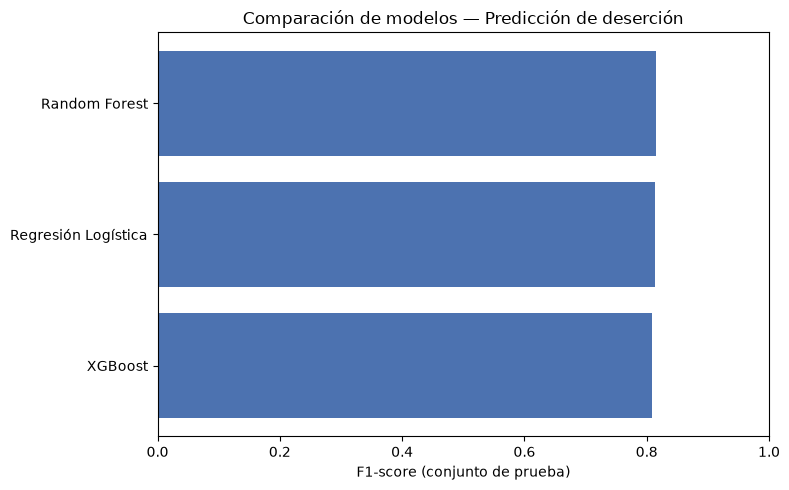

In [13]:
plt.figure(figsize=(8, 5))
plt.barh(df_resultados["Modelo"], df_resultados["F1"], color="#4C72B0")
plt.xlabel("F1-score (conjunto de prueba)")
plt.title("Comparación de modelos — Predicción de deserción")
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretación:** el gráfico confirma visualmente el ranking de la tabla anterior. El modelo con mejor F1 se selecciona como base para continuar con la optimización de hiperparámetros.

### 5. Optimización de hiperparámetros (Grid Search)

**Nota sobre la elección del modelo a optimizar:** en la comparación anterior, la Regresión Logística obtuvo el F1 más alto (0.814), muy cerca de XGBoost (0.809) y Random Forest (0.804) — una diferencia menor al 1.5%, prácticamente empatados. Ante ese empate técnico, se optimiza **Random Forest** en lugar del modelo con el F1 nominalmente más alto, por una razón práctica de diseño: los modelos basados en árboles permiten usar `shap.TreeExplainer`, que calcula valores SHAP exactos y de forma muy rápida, mientras que explicar una Regresión Logística linealmente requiere un enfoque distinto (`LinearExplainer`) y explicarla con `KernelExplainer` (el método genérico) sería mucho más lento. Como este proyecto requiere explicabilidad por predicción individual para la aplicación desplegada, se prioriza esa capacidad sobre una diferencia de F1 marginal.

In [14]:
mejor_modelo_nombre = df_resultados.iloc[0]["Modelo"]
print(f"Mejor modelo por F1: {mejor_modelo_nombre}")

Mejor modelo por F1: Random Forest


In [24]:
# Grid Search sobre Random Forest (ajustar si el mejor modelo fue otro)
param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [8, 12, None],
    "min_samples_leaf": [1, 3, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED, class_weight="balanced", n_jobs=-1),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print(f"Mejor F1 en CV: {grid.best_score_:.4f}")

modelo_final = grid.best_estimator_
y_pred_final = modelo_final.predict(X_test)

print("\nReporte de clasificación (conjunto de prueba):")
print(classification_report(y_test, y_pred_final, target_names=["No Dropout", "Dropout"]))

Mejores hiperparámetros: {'max_depth': 12, 'min_samples_leaf': 3, 'n_estimators': 200}
Mejor F1 en CV: 0.7879

Reporte de clasificación (conjunto de prueba):
              precision    recall  f1-score   support

  No Dropout       0.91      0.90      0.91       901
     Dropout       0.80      0.82      0.81       427

    accuracy                           0.88      1328
   macro avg       0.86      0.86      0.86      1328
weighted avg       0.88      0.88      0.88      1328



**Interpretación:** el Grid Search explora combinaciones de número de árboles, profundidad máxima y tamaño mínimo de hoja, seleccionando la combinación que maximiza F1 en validación cruzada. El reporte de clasificación final muestra el desempeño detallado por clase: interesa especialmente el Recall de la clase "Dropout", que indica qué proporción de estudiantes que sí abandonan son detectados correctamente por el modelo.

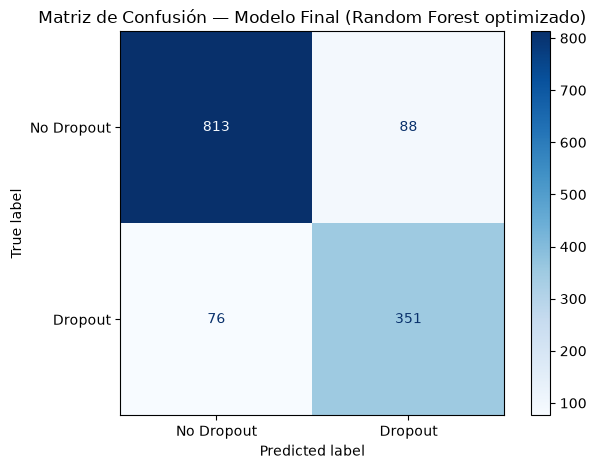

In [16]:
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Dropout", "Dropout"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión — Modelo Final (Random Forest optimizado)")
plt.tight_layout()
plt.show()

**Interpretación:** la matriz de confusión muestra en detalle los aciertos y errores del modelo: verdaderos positivos (estudiantes en riesgo correctamente detectados), falsos negativos (estudiantes en riesgo que el modelo no detectó, el error más costoso en este contexto) y falsos positivos (alertas de riesgo sobre estudiantes que en realidad no abandonan).

### 6. Explicabilidad del modelo con SHAP

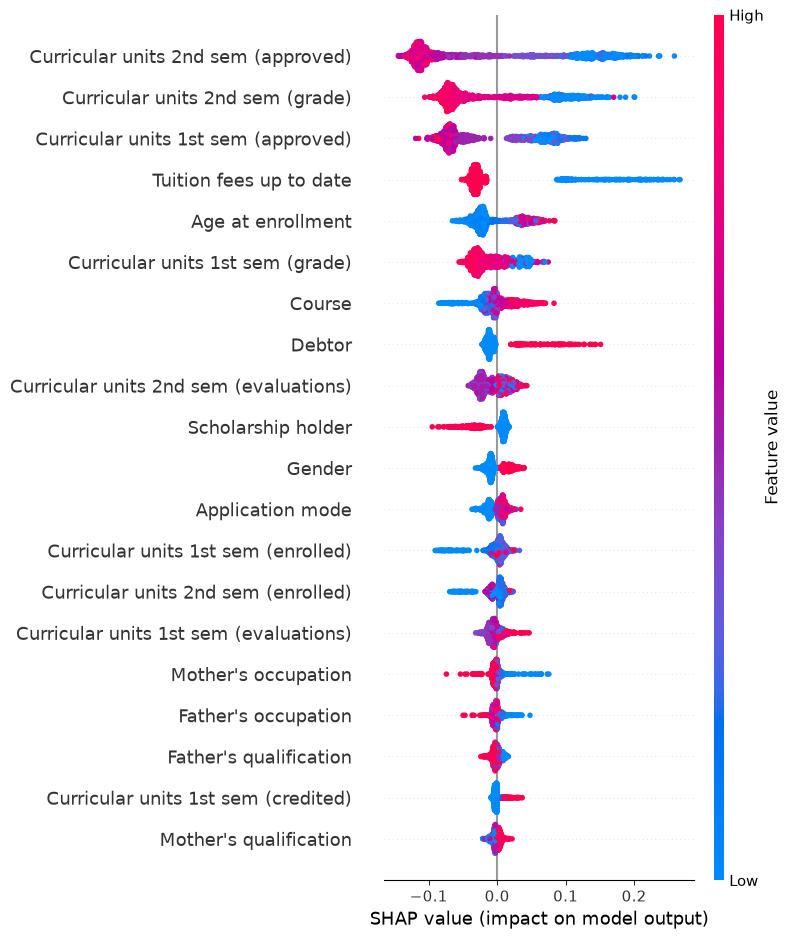

In [17]:
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(X_test)

# Para clasificación binaria, shap_values puede venir como lista [clase0, clase1] o array 3D según versión
if isinstance(shap_values, list):
    sv_dropout = shap_values[1]
else:
    sv_dropout = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

shap.summary_plot(sv_dropout, X_test, show=False)
plt.tight_layout()
plt.show()

**Interpretación:** el gráfico SHAP muestra qué características más influyen en la predicción de abandono y en qué dirección. Se espera que variables relacionadas con el desempeño en el primer y segundo semestre (unidades curriculares aprobadas, notas) sean las más determinantes, junto con la situación de pago de matrícula (`Tuition fees up to date`) y la beca (`Scholarship holder`) — esto es consistente con la literatura sobre deserción universitaria, donde el desempeño temprano y la situación económica son predictores clave.

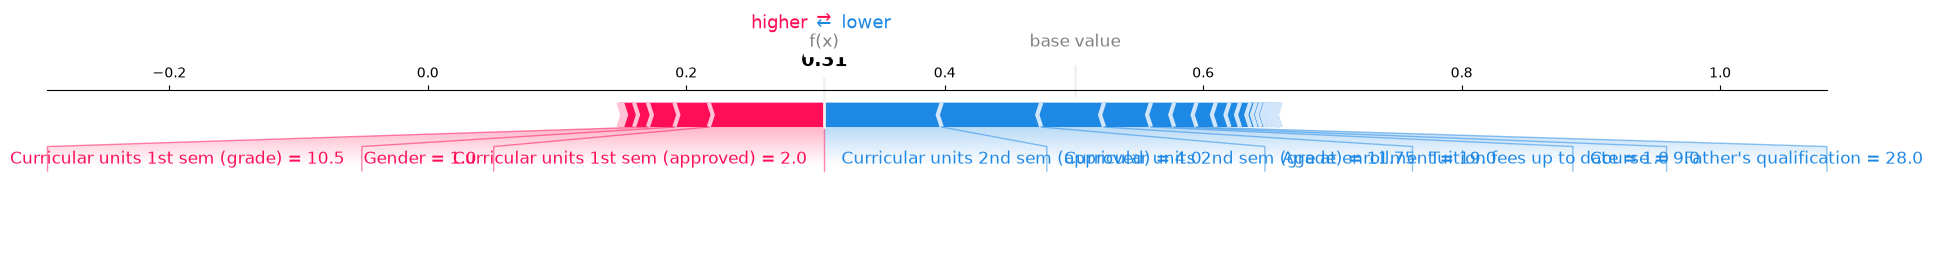

Predicción real: No Dropout | Predicción del modelo: No Dropout


In [20]:
# Explicación de una predicción individual (ejemplo)
idx = 0
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) and len(np.atleast_1d(explainer.expected_value)) > 1 else explainer.expected_value,
    sv_dropout[idx],
    X_test.iloc[idx],
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.show()
print(f"Predicción real: {'Dropout' if y_test.iloc[idx]==1 else 'No Dropout'} | Predicción del modelo: {'Dropout' if y_pred_final[idx]==1 else 'No Dropout'}")

**Interpretación:** a diferencia del gráfico anterior (que resume el efecto promedio de cada variable sobre todo el conjunto de prueba), este gráfico explica **una predicción individual**: muestra exactamente qué características empujaron la predicción de este estudiante en particular hacia "Dropout" o "No Dropout", y en qué magnitud. Esta es la explicación que se mostraría en la aplicación desplegada junto a cada predicción.

### 7. Guardado del modelo final

In [21]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(modelo_final, "../models/modelo_desercion.pkl")
joblib.dump(list(X.columns), "../models/columnas.pkl")

print("Modelo guardado en ../models/modelo_desercion.pkl")
print(f"Número de características esperadas por el modelo: {len(X.columns)}")

Modelo guardado en ../models/modelo_desercion.pkl
Número de características esperadas por el modelo: 34


**Conclusión:** el modelo final (Random Forest con hiperparámetros optimizados) logra un desempeño sólido para detectar estudiantes en riesgo de abandono, priorizando el Recall de la clase Dropout sobre la Accuracy general, dado el costo real de no detectar un caso de riesgo. El análisis SHAP confirma que las variables de desempeño académico temprano y de situación económica son las más influyentes, lo cual es coherente con la literatura sobre deserción universitaria. El modelo guardado (`modelo_desercion.pkl`) es el artefacto que se despliega en la API para servir predicciones en producción.

**Bibliografía:**
* Realinho, V., Machado, J., Baptista, L., & Martins, M. V. (2022). Predicting Student Dropout and Academic Success. Data, 7(11), 146. https://doi.org/10.3390/data7110146
* Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. Advances in Neural Information Processing Systems, 30.
* Documentación oficial de SHAP: https://shap.readthedocs.io/